# Lab - Intervalo de Confiança

* A partir o dataset IRIS (já trabalhado na aula), gere um novo dataset contendo apenas 1 das 4 medidas disponíveis no dataset original (Sepal Lentgh, Setal Width, Petal Length, Petal Width). Além disso, remova todas as linhas referentes a um dos tipos de flor e mantenha apenas 2 tipos ao invés dos 3 contidos no datset original (Setosa, Versicolour e Virginica). Ou seja, seu dataset conterá 1 coluna e 100 linhas (há 50 amostras de cada tipo de flor no datset original).

* Usando bootstrap para gerar o intervalo de confiança, calcule a diferença entre as médias para os dois tipos de flor.

* Informe o seu resultado em uma frase do tipo: "Com 95% de confiança, podemos afirmar que, em média, os cachorros são mais altos do que os gatos em 20,3cm, com intervalo de confiança de 17,2cm a 23,5cm".

* **Use o dataset inteiro** considerando que ele representa toda a amostra que você conseguiu coletar. Observe que isso é diferente do que fizemos em aula, onde consideramos que as 150 flores eram todas as existentes e nossa amostra continha uma quantidade menor (20, 30, por exemplo).

* Dependendo da forma como você pretenda resolver o problema, você pode ter interesse em alterar a função bootstrap disponibilizada abaixo. Fique à vontade para gerar variações dessa função se assim desejar.



## Dados do(a) aluno(a)

**Nome**: Orlando Virginio Penha Junior

**Matrícula**: 122210927

## Imports.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample
import seaborn as sns

## Carregando o Datset Original

In [2]:
from sklearn import datasets
iris = datasets.load_iris()

In [3]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [4]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [7]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

## Gerando o novo Dataset

### Parte 1

In [8]:
# Escolhendo petal length e retirando virginica, Ficando apenas com ('setosa', 'versicolor')
df_lab = pd.DataFrame(iris.data, columns=iris.feature_names)
df_lab['target'] = iris.target

In [9]:
df_lab.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df_lab = df_lab[df_lab['target'] != 2].loc[:,['petal length (cm)', 'target']]

In [11]:
df_lab.head()

,petal length (cm),target
0,1.4,0
1,1.4,0
2,1.3,0
3,1.5,0
4,1.4,0


## Definição da função de Bootstrap

Dependendo da forma como você pretenda resolver o problema, você pode ter interesse em alterar a função bootstrap disponibilizada abaixo. Fique à vontade para gerar variações dessa função se assim desejar.

In [12]:
def bootstrap(data, func, alpha=0.95, n_rep=1000):

  df_setosa = data[data['target'] == 0]
  df_versicolor = data[data['target'] == 1]

  theta_hat_error_list = list()

  theta_setosa = func(df_setosa['petal length (cm)'])
  theta_versicolor = func(df_versicolor['petal length (cm)'])

  theta = theta_setosa - theta_versicolor

  # Resampling
  for _ in range(0,n_rep):

    x_setosa = resample(df_setosa, replace=True)
    x_versicolor = resample(df_versicolor, replace=True)
    theta_hat_error = (func(x_setosa['petal length (cm)']) - func(x_versicolor['petal length (cm)'])) - theta
    theta_hat_error_list.append(theta_hat_error)
    
  # Percentiles
  lower_p = ((1.0-alpha)/2.0) * 100
  upper_p = (alpha+((1.0-alpha)/2.0)) * 100

  # Lower and Upper Bounds
  lower_value = np.percentile(theta_hat_error_list, lower_p)
  upper_value = np.percentile(theta_hat_error_list, upper_p)

  lower_limit = theta + lower_value
  upper_limit = theta + upper_value

  return theta, lower_limit, upper_limit, theta_hat_error_list,lower_value,upper_value

## Análise das diferenças entre os dois tipos de flor escolhidos.

In [13]:
theta, lower_limit, upper_limit, theta_hat_error_list,lower_value,upper_value = bootstrap(df_lab,np.mean)
print(f"Diferença de média entre setosa e versicolor: {theta:.2f}\n"+
      f"Limite inferor: {lower_limit:.2f}\n"+
      f"Limite superior: {upper_limit:.2f}")

Diferença de média entre setosa e versicolor: -2.80
Limite inferor: -2.93
Limite superior: -2.66


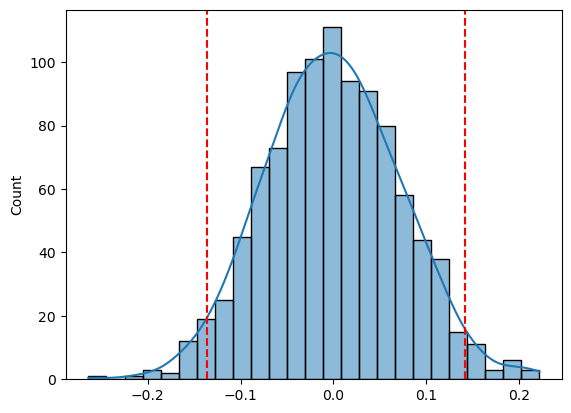

In [14]:
sns.histplot(theta_hat_error_list,kde=True)
plt.axvline(x=lower_value,linestyle='--',color='red')
plt.axvline(x=upper_value,linestyle='--',color='red')


### Gerando vários cenários

In [15]:
contador = 0
for i in range(0,100):
  sample_to_bootstrap = resample(df_lab, n_samples=len(df_lab), replace=False)
  theta_bs, lower_limit, upper_limit, _,_,_ = bootstrap(sample_to_bootstrap, func=np.mean,alpha=0.95, n_rep=1000)
  contains_theta = (lower_limit <= theta <= upper_limit)
  if contains_theta:
    contador += 1
  print('%.3f -- %.3f | %s' % (lower_limit, upper_limit, contains_theta))
print(f"\n{contador}%")

-2.940 -- -2.654 | True
-2.932 -- -2.658 | True
-2.932 -- -2.656 | True
-2.930 -- -2.660 | True
-2.932 -- -2.650 | True
-2.934 -- -2.656 | True
-2.926 -- -2.654 | True
-2.930 -- -2.652 | True
-2.928 -- -2.658 | True
-2.942 -- -2.662 | True
-2.922 -- -2.656 | True
-2.930 -- -2.660 | True
-2.928 -- -2.654 | True
-2.928 -- -2.656 | True
-2.930 -- -2.664 | True
-2.938 -- -2.658 | True
-2.936 -- -2.656 | True
-2.922 -- -2.654 | True
-2.926 -- -2.662 | True
-2.942 -- -2.672 | True
-2.932 -- -2.662 | True
-2.932 -- -2.652 | True
-2.932 -- -2.650 | True
-2.934 -- -2.652 | True
-2.934 -- -2.664 | True
-2.934 -- -2.656 | True
-2.928 -- -2.658 | True
-2.922 -- -2.654 | True
-2.932 -- -2.652 | True
-2.926 -- -2.658 | True
-2.926 -- -2.664 | True
-2.934 -- -2.656 | True
-2.938 -- -2.662 | True
-2.928 -- -2.668 | True
-2.934 -- -2.652 | True
-2.934 -- -2.656 | True
-2.930 -- -2.660 | True
-2.934 -- -2.656 | True
-2.930 -- -2.664 | True
-2.942 -- -2.662 | True
-2.934 -- -2.658 | True
-2.938 -- -2.658

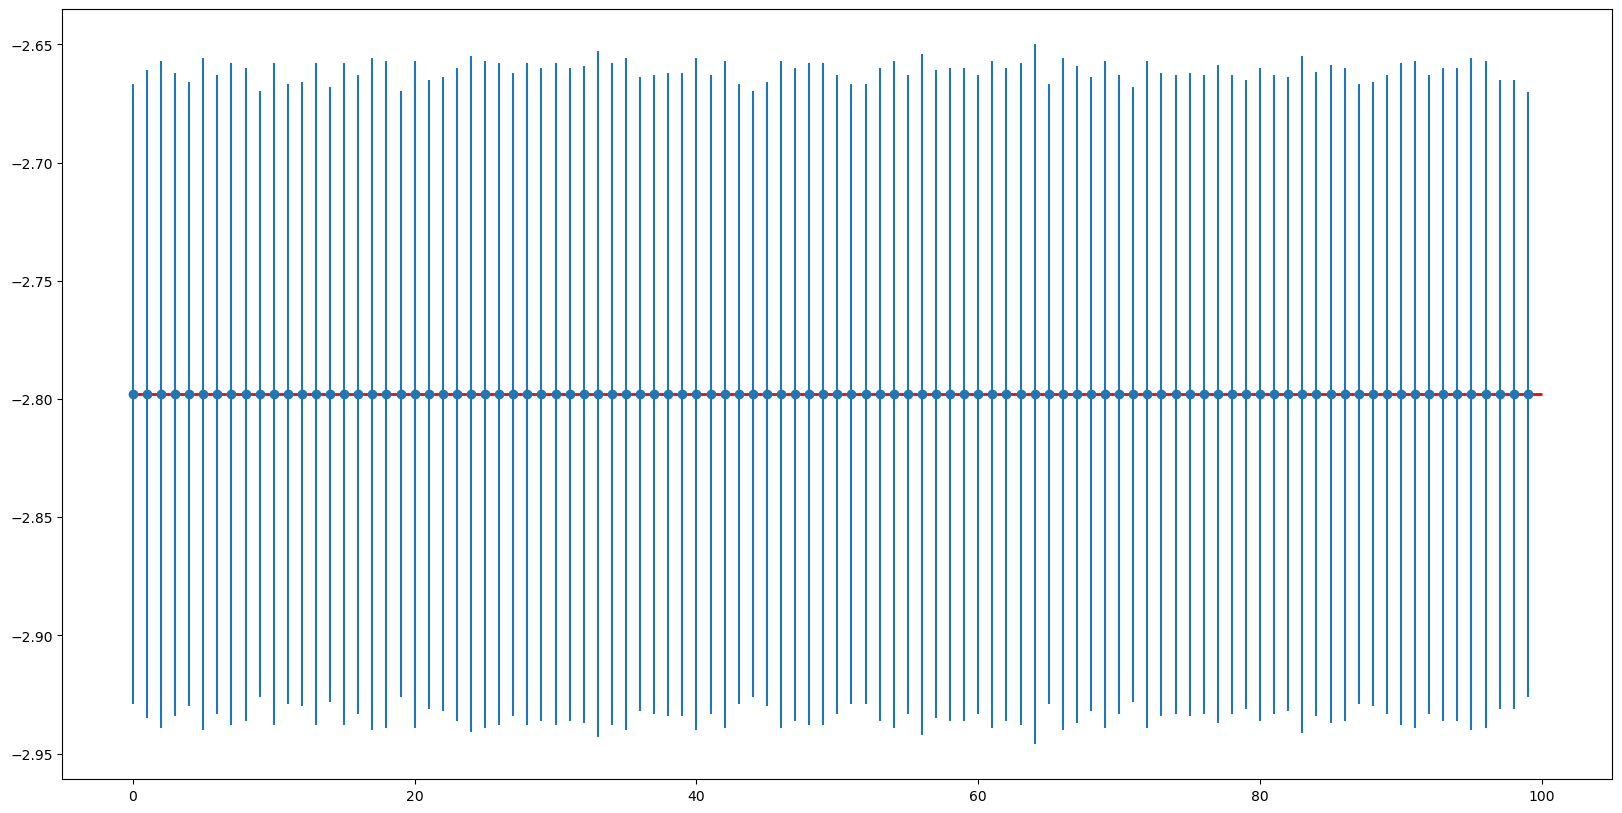

In [16]:
intervals = []
thetas_hat = []


for i in range(0,100):
  sample_to_bootstrap = resample(df_lab, n_samples=len(df_lab), replace=False)
  theta_bs, lower_limit, upper_limit,_,_,_ = bootstrap(sample_to_bootstrap, alpha=0.95, func=np.mean)
  thetas_hat.append(theta_bs)
  intervals.append((lower_limit, upper_limit))

plt.figure(figsize=(20,10))

plt.errorbar(x=np.arange(0, 100, 1),
             y=thetas_hat,
             yerr=[(ur-lr)/2 for lr,ur in intervals],
             fmt='o')

plt.hlines(xmin=0, xmax=100,
           y=theta,
           linewidth=2.0,
           color="red");

Resultado:

Com 95% de confiança, podemos afirmar que, em média, as flores do tipo setosa são menores do que as flores do tipo versicolor em 2,80cm, com intervalo de confiança para a diferença entre as médias de -2,93cm a -2,66cm.